Shape of Dataset: (1250, 7)

Columns:
 Index(['daily_screen_time', 'avg_session_duration', 'night_usage',
       'brightness_level', 'dark_mode_usage', 'ambient_light', 'Gender'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   daily_screen_time     1212 non-null   float64
 1   avg_session_duration  1212 non-null   float64
 2   night_usage           1212 non-null   float64
 3   brightness_level      1212 non-null   float64
 4   dark_mode_usage       1212 non-null   float64
 5   ambient_light         1212 non-null   float64
 6   Gender                1212 non-null   object 
dtypes: float64(6), object(1)
memory usage: 68.5+ KB
None

First 5 Rows:

   daily_screen_time  avg_session_duration  night_usage  brightness_level  \
0                5.2                  20.0          0.0           

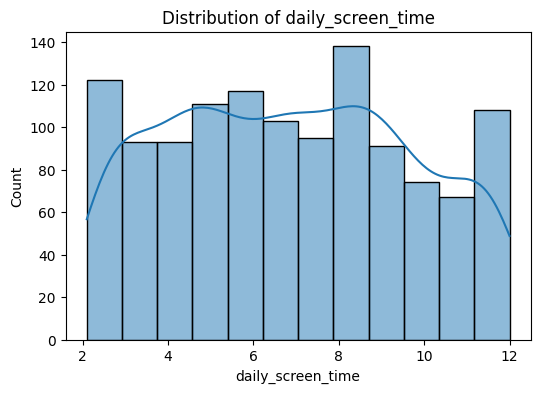

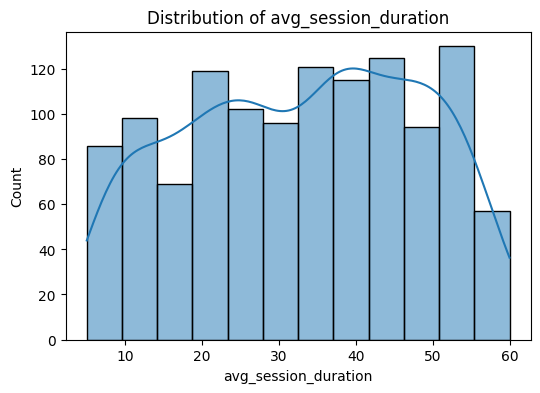

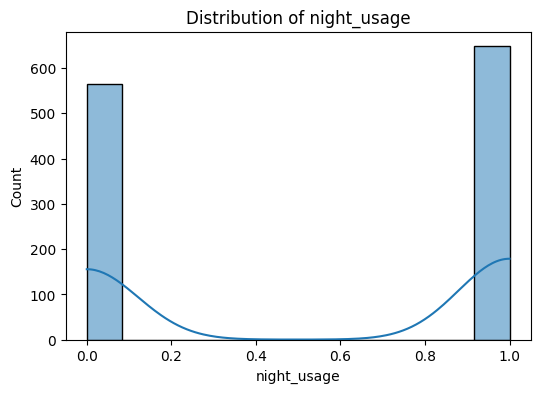

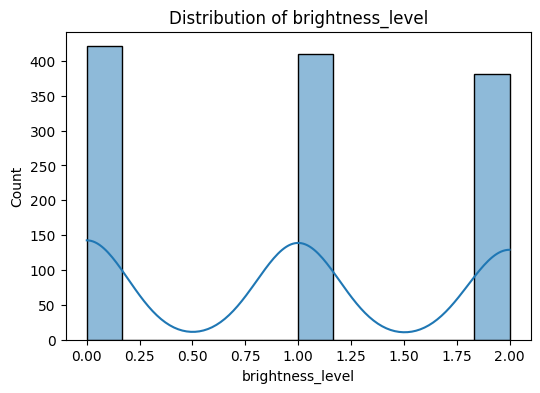

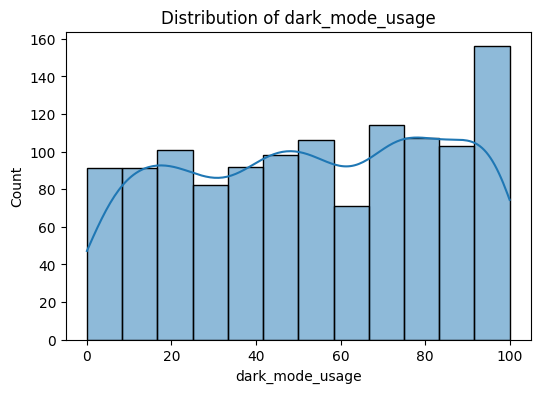

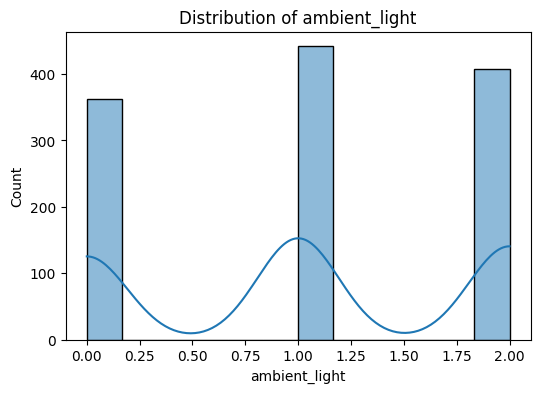

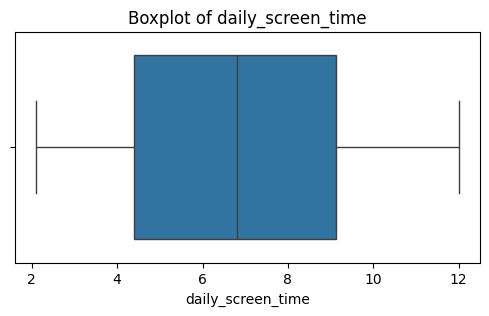

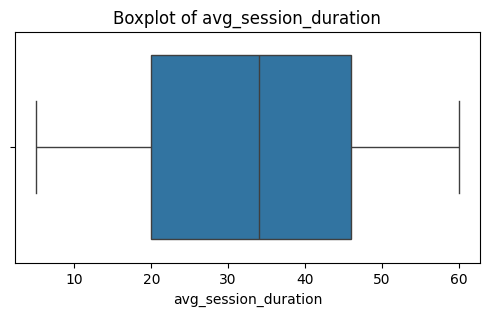

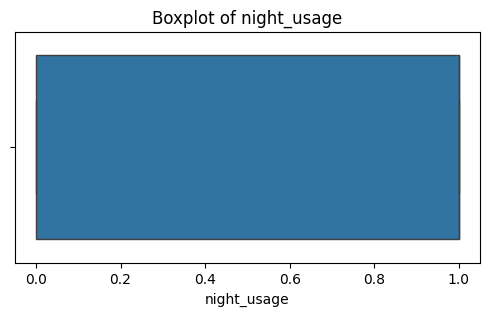

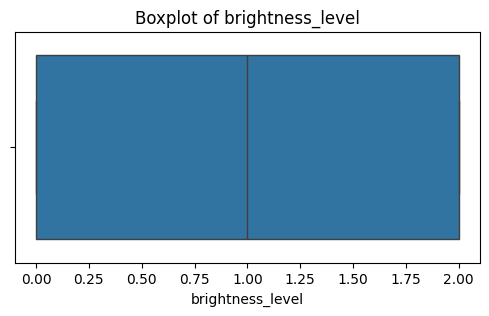

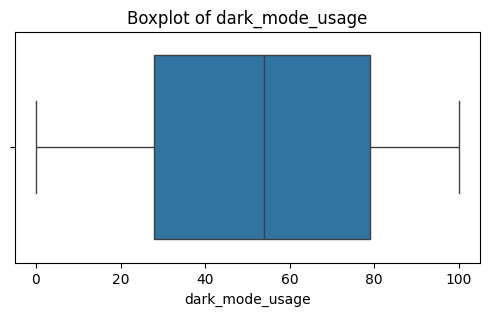

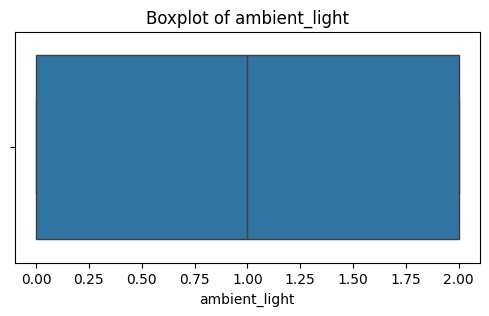

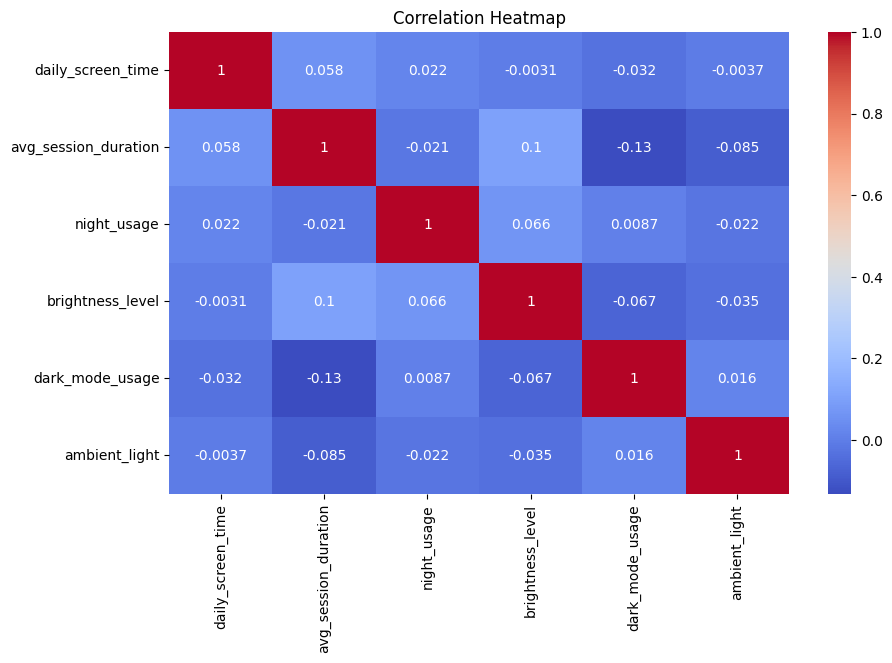

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Eye_strain_dataset.csv")


print("Shape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)

print("\nDataset Info:\n")
print(df.info())


print("\nFirst 5 Rows:\n")
print(df.head())

print("\nLast 5 Rows:\n")
print(df.tail())


print("\nStatistical Summary:\n")
print(df.describe(include='all'))



print("\nMissing Values Count:\n")
print(df.isnull().sum())


print("\nTotal Duplicate Rows:", df.duplicated().sum())


categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\nValue Counts for {col}:\n")
    print(df[col].value_counts(dropna=False))


numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


plt.figure(figsize=(10, 6))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()




Shape of Dataset: (1000, 10)

Column Names:
 Index(['User_ID', 'Age', 'Gender', 'Total_App_Usage_Hours',
       'Daily_Screen_Time_Hours', 'Number_of_Apps_Used',
       'Social_Media_Usage_Hours', 'Productivity_App_Usage_Hours',
       'Gaming_App_Usage_Hours', 'Location'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   object 
 3   Total_App_Usage_Hours         1000 non-null   float64
 4   Daily_Screen_Time_Hours       1000 non-null   float64
 5   Number_of_Apps_Used           1000 non-null   int64  
 6   Social_Media_Usage_Hours      1000 non-null   float64
 7   Productivity_App_Usage_Hours  1000 non-null  

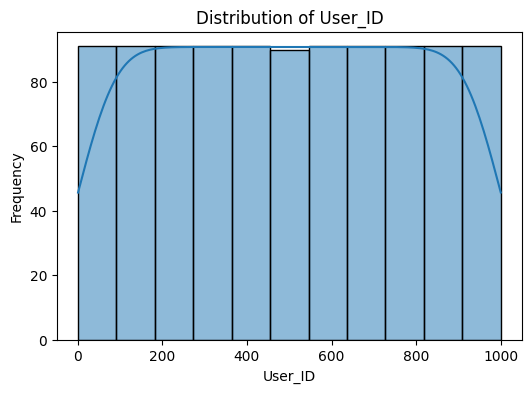

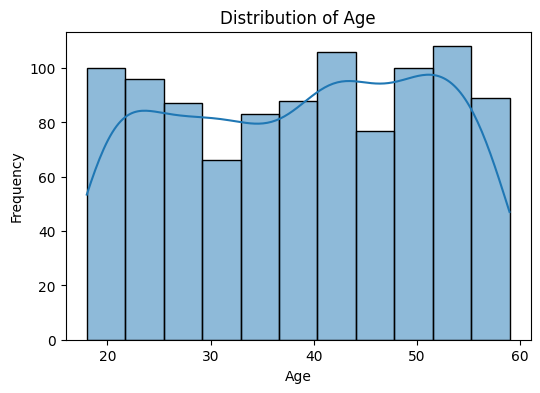

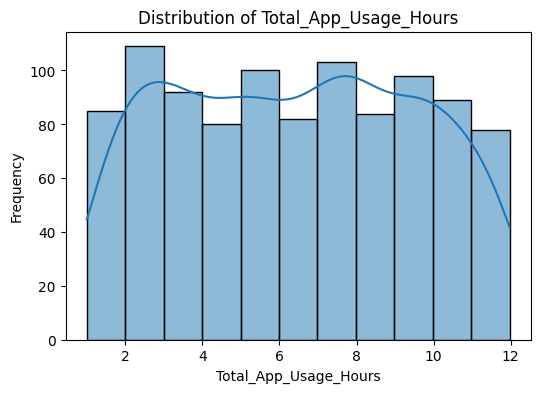

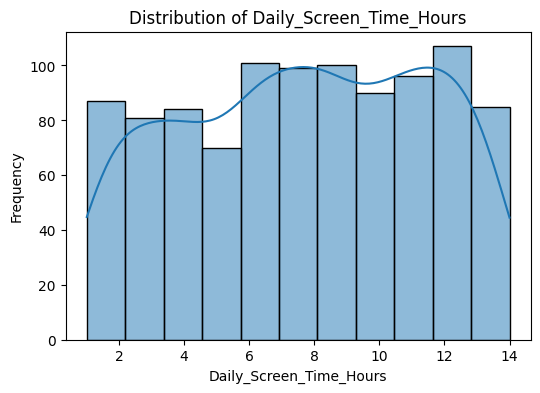

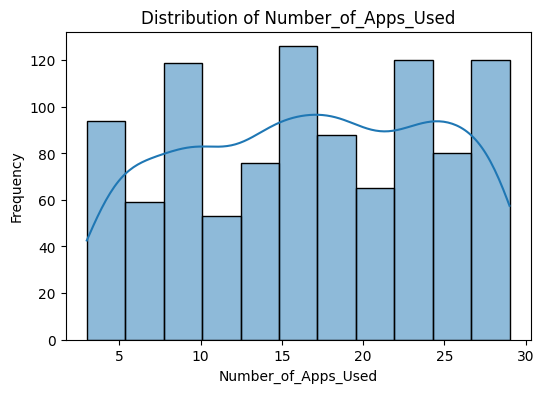

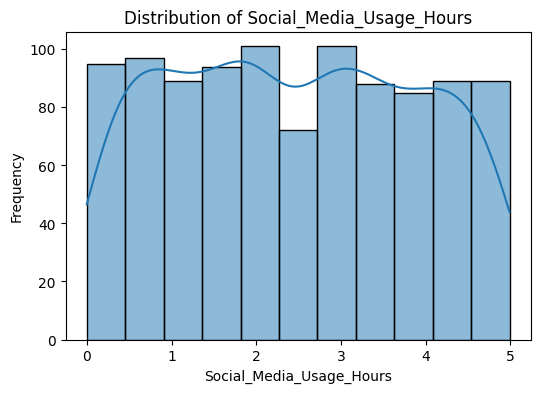

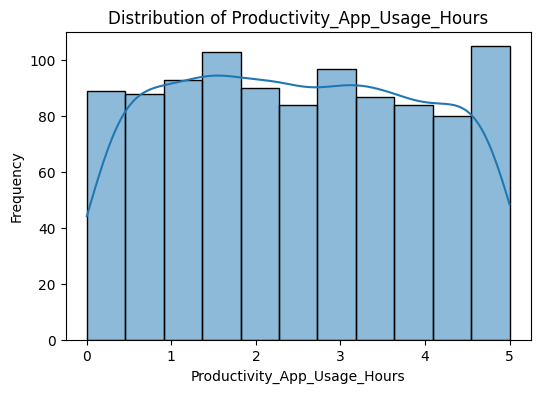

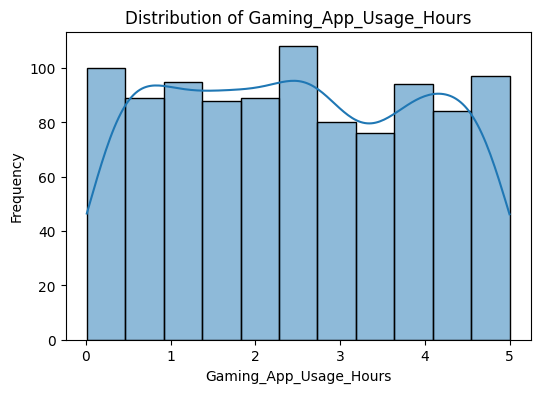

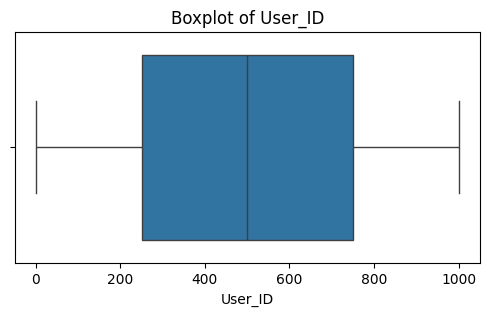

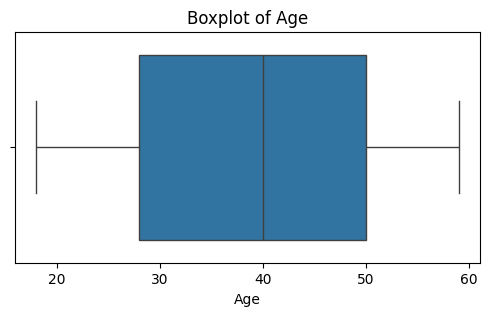

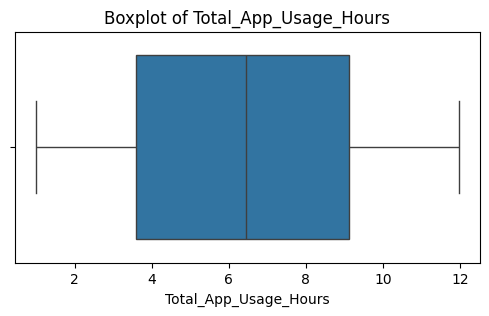

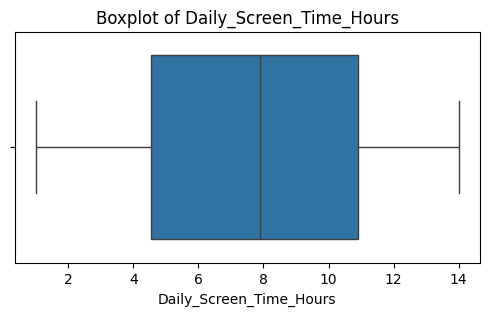

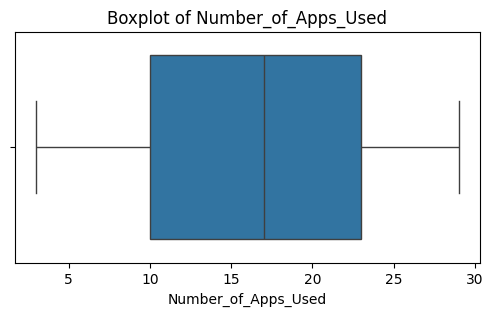

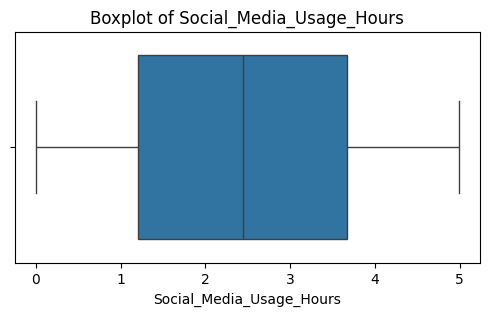

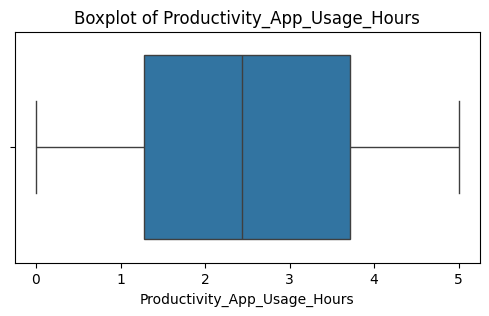

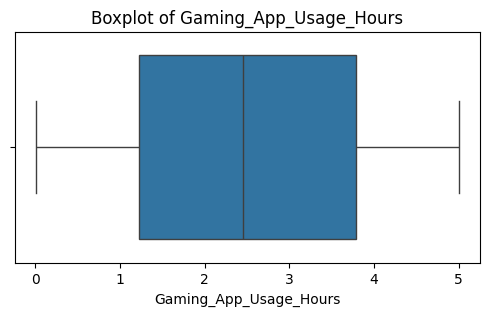

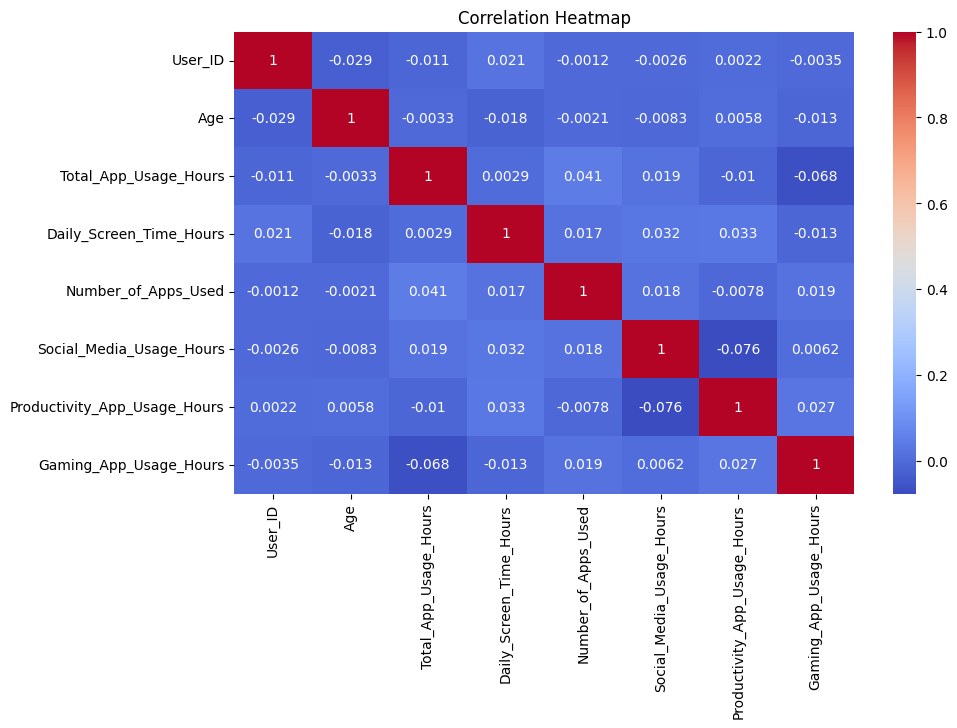

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Kaggle_dataset.csv")


print("Shape of Dataset:", df.shape)
print("\nColumn Names:\n", df.columns)


print("\nDataset Info:\n")
df.info()


print("\nFirst 5 Rows:\n")
print(df.head())

print("\nLast 5 Rows:\n")
print(df.tail())


print("\nStatistical Summary:\n")
print(df.describe(include='all'))


print("\nMissing Values Count:\n")
print(df.isnull().sum())

print("\nMissing Values Percentage:\n")
print((df.isnull().sum() / len(df)) * 100)


print("\nTotal Duplicate Rows:", df.duplicated().sum())


categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\nValue Counts for {col}:\n")
    print(df[col].value_counts(dropna=False))


numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()



plt.figure(figsize=(10, 6))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()




         Eye_strain_dataset  Kaggle_dataset
Rows                   1250            1000
Columns                   7              10


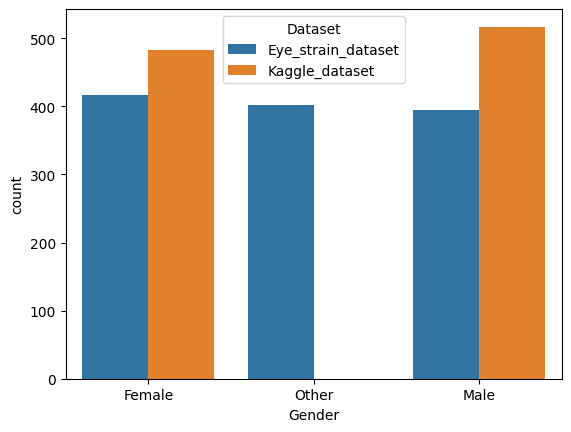

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Eye_strain_dataset = pd.read_csv("Eye_strain_dataset.csv")
Kaggle_dataset = pd.read_csv("Kaggle_dataset.csv")

common_num_cols = list(set(Eye_strain_dataset.select_dtypes(include="number").columns)
                       & set(Kaggle_dataset.select_dtypes(include="number").columns))

common_cat_cols = list(set(Eye_strain_dataset.select_dtypes(include="object").columns)
                       & set(Kaggle_dataset.select_dtypes(include="object").columns))

print(pd.DataFrame({
    "Eye_strain_dataset": Eye_strain_dataset.shape,
    "Kaggle_dataset": Kaggle_dataset.shape
}, index=["Rows", "Columns"]))

if len(common_num_cols) > 0:
    for col in common_num_cols:
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        sns.histplot(Eye_strain_dataset[col], kde=True)
        plt.title(f"{col} - Eye_strain_dataset")
        plt.subplot(1,2,2)
        sns.histplot(Kaggle_dataset[col], kde=True)
        plt.title(f"{col} - Kaggle_dataset")
        plt.show()

        sns.boxplot(
            data=pd.concat([
                Eye_strain_dataset[[col]].assign(Dataset="Eye_strain_dataset"),
                Kaggle_dataset[[col]].assign(Dataset="Kaggle_dataset")
            ], ignore_index=True),
            x="Dataset",
            y=col
        )
        plt.show()

        sns.violinplot(
            data=pd.concat([
                Eye_strain_dataset[[col]].assign(Dataset="Eye_strain_dataset"),
                Kaggle_dataset[[col]].assign(Dataset="Kaggle_dataset")
            ], ignore_index=True),
            x="Dataset",
            y=col
        )
        plt.show()

        plt.figure(figsize=(8,4))
        sns.kdeplot(Eye_strain_dataset[col], label="Eye_strain_dataset", fill=True)
        sns.kdeplot(Kaggle_dataset[col], label="Kaggle_dataset", fill=True)
        plt.legend()
        plt.title(col)
        plt.show()

        plt.figure(figsize=(8,4))
        sns.ecdfplot(Eye_strain_dataset[col], label="Eye_strain_dataset")
        sns.ecdfplot(Kaggle_dataset[col], label="Kaggle_dataset")
        plt.legend()
        plt.title(col)
        plt.show()

    stats = pd.DataFrame({
        "Eye_strain_Mean": Eye_strain_dataset[common_num_cols].mean(),
        "Kaggle_Mean": Kaggle_dataset[common_num_cols].mean(),
        "Eye_strain_Median": Eye_strain_dataset[common_num_cols].median(),
        "Kaggle_Median": Kaggle_dataset[common_num_cols].median()
    })

    stats.plot(kind="bar", figsize=(12,5))
    plt.show()

    if len(common_num_cols) > 1:
        fig, axes = plt.subplots(1,2, figsize=(14,6))
        sns.heatmap(Eye_strain_dataset[common_num_cols].corr(), ax=axes[0], annot=True)
        axes[0].set_title("Eye_strain_dataset Correlation")
        sns.heatmap(Kaggle_dataset[common_num_cols].corr(), ax=axes[1], annot=True)
        axes[1].set_title("Kaggle_dataset Correlation")
        plt.show()

if len(common_cat_cols) > 0:
    for col in common_cat_cols:
        sns.countplot(
            data=pd.concat([
                Eye_strain_dataset[[col]].assign(Dataset="Eye_strain_dataset"),
                Kaggle_dataset[[col]].assign(Dataset="Kaggle_dataset")
            ], ignore_index=True),
            x=col,
            hue="Dataset"
        )
        plt.show()


===== BASIC COMPARISON =====

Eye Strain Dataset Shape: (1250, 7)
Kaggle Dataset Shape: (1000, 10)

Eye Strain Dataset Columns:
 Index(['daily_screen_time', 'avg_session_duration', 'night_usage',
       'brightness_level', 'dark_mode_usage', 'ambient_light', 'Gender'],
      dtype='object')

Kaggle Dataset Columns:
 Index(['User_ID', 'Age', 'Gender', 'Total_App_Usage_Hours',
       'Daily_Screen_Time_Hours', 'Number_of_Apps_Used',
       'Social_Media_Usage_Hours', 'Productivity_App_Usage_Hours',
       'Gaming_App_Usage_Hours', 'Location'],
      dtype='object')

===== EYE STRAIN DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   daily_screen_time     1212 non-null   float64
 1   avg_session_duration  1212 non-null   float64
 2   night_usage           1212 non-null   float64
 3   brightness_level      1212 

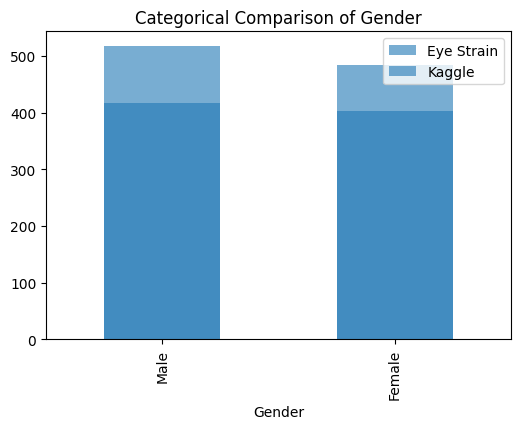

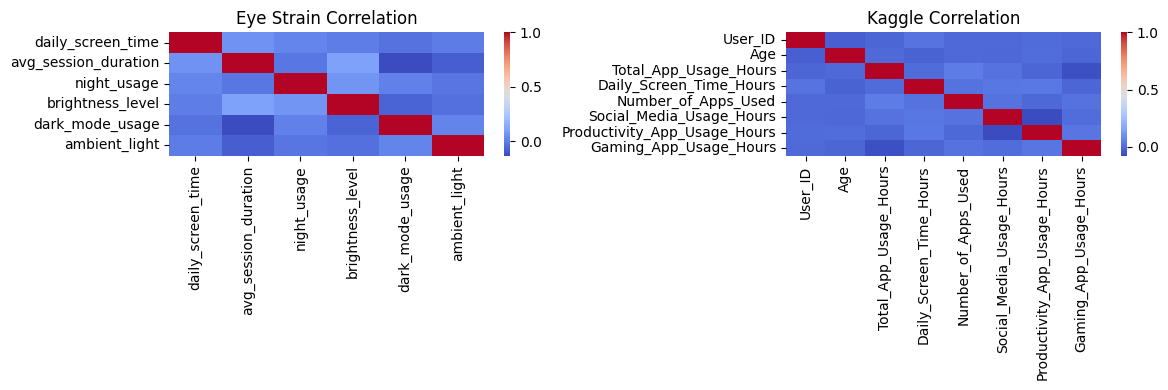

In [26]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


eye_df = pd.read_csv("Eye_strain_dataset.csv")
kaggle_df = pd.read_csv("Kaggle_dataset.csv")


print("===== BASIC COMPARISON =====")
print("\nEye Strain Dataset Shape:", eye_df.shape)
print("Kaggle Dataset Shape:", kaggle_df.shape)

print("\nEye Strain Dataset Columns:\n", eye_df.columns)
print("\nKaggle Dataset Columns:\n", kaggle_df.columns)


print("\n===== EYE STRAIN DATASET INFO =====")
eye_df.info()

print("\n===== KAGGLE DATASET INFO =====")
kaggle_df.info()


missing_comparison = pd.DataFrame({
    "Eye_Strain_Missing": eye_df.isnull().sum(),
    "Kaggle_Missing": kaggle_df.isnull().sum()
})

print("\n===== MISSING VALUES COMPARISON =====")
print(missing_comparison)


print("\n===== DUPLICATE ROWS =====")
print("Eye Strain Dataset Duplicates:", eye_df.duplicated().sum())
print("Kaggle Dataset Duplicates:", kaggle_df.duplicated().sum())


print("\n===== STATISTICAL SUMMARY (EYE STRAIN) =====")
print(eye_df.describe(include='all'))

print("\n===== STATISTICAL SUMMARY (KAGGLE) =====")
print(kaggle_df.describe(include='all'))


eye_num_cols = eye_df.select_dtypes(include=np.number).columns
kaggle_num_cols = kaggle_df.select_dtypes(include=np.number).columns

common_numerical_cols = set(eye_num_cols).intersection(set(kaggle_num_cols))

for col in common_numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(eye_df[col], label="Eye Strain Dataset")
    sns.kdeplot(kaggle_df[col], label="Kaggle Dataset")
    plt.title(f"Distribution Comparison of {col}")
    plt.legend()
    plt.show()


eye_cat_cols = eye_df.select_dtypes(include='object').columns
kaggle_cat_cols = kaggle_df.select_dtypes(include='object').columns

common_categorical_cols = set(eye_cat_cols).intersection(set(kaggle_cat_cols))

for col in common_categorical_cols:
    plt.figure(figsize=(6, 4))
    eye_df[col].value_counts().plot(kind='bar', alpha=0.6, label="Eye Strain")
    kaggle_df[col].value_counts().plot(kind='bar', alpha=0.6, label="Kaggle")
    plt.title(f"Categorical Comparison of {col}")
    plt.legend()
    plt.show()


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(eye_df[eye_num_cols].corr(), cmap='coolwarm')
plt.title("Eye Strain Correlation")

plt.subplot(1, 2, 2)
sns.heatmap(kaggle_df[kaggle_num_cols].corr(), cmap='coolwarm')
plt.title("Kaggle Correlation")

plt.tight_layout()
plt.show()




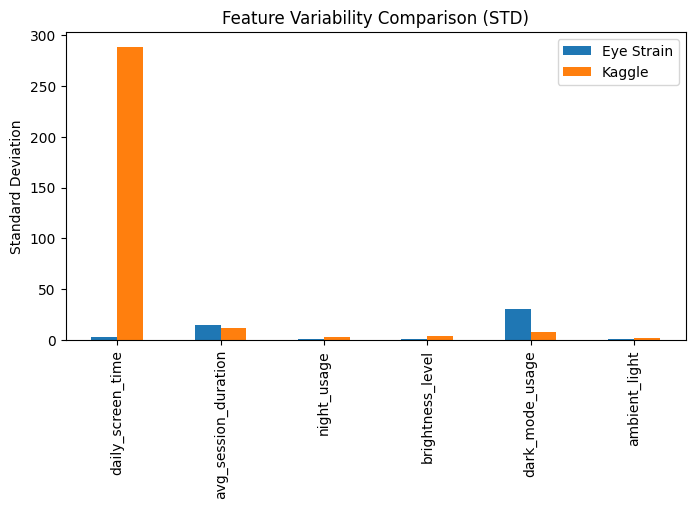

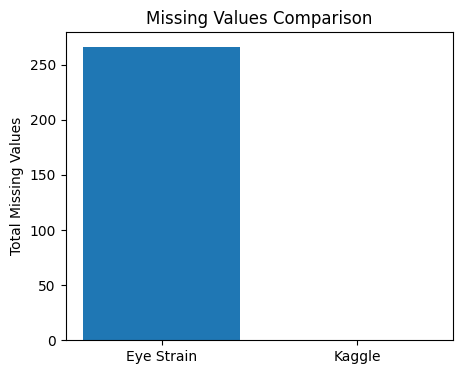

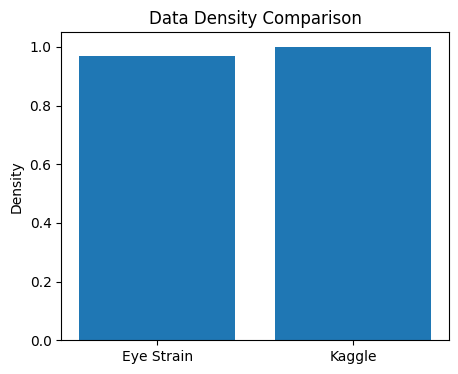

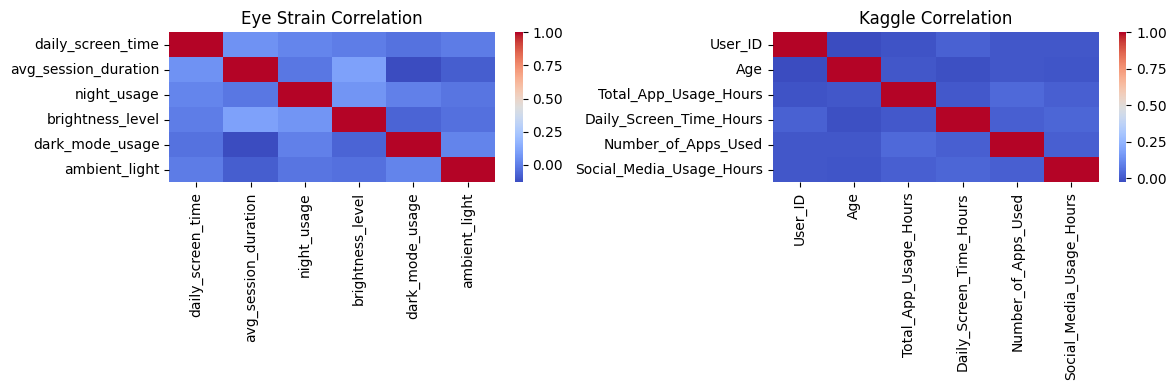

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

eye_df = pd.read_csv("Eye_strain_dataset.csv")
kaggle_df = pd.read_csv("Kaggle_dataset.csv")

eye_num = eye_df.select_dtypes(include=np.number)
kaggle_num = kaggle_df.select_dtypes(include=np.number)

min_features = min(len(eye_num.columns), len(kaggle_num.columns))

eye_num = eye_num.iloc[:, :min_features]
kaggle_num = kaggle_num.iloc[:, :min_features]

std_df = pd.DataFrame({
    "Eye Strain": eye_num.std().values,
    "Kaggle": kaggle_num.std().values
}, index=eye_num.columns)

std_df.plot(kind="bar", figsize=(8,4))
plt.title("Feature Variability Comparison (STD)")
plt.ylabel("Standard Deviation")
plt.show()

eye_missing = eye_df.isnull().sum().sum()
kaggle_missing = kaggle_df.isnull().sum().sum()

plt.figure(figsize=(5,4))
plt.bar(["Eye Strain", "Kaggle"], [eye_missing, kaggle_missing])
plt.title("Missing Values Comparison")
plt.ylabel("Total Missing Values")
plt.show()

eye_density = 1 - (eye_missing / eye_df.size)
kaggle_density = 1 - (kaggle_missing / kaggle_df.size)

plt.figure(figsize=(5,4))
plt.bar(["Eye Strain", "Kaggle"], [eye_density, kaggle_density])
plt.title("Data Density Comparison")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.heatmap(eye_num.corr(), cmap="coolwarm")
plt.title("Eye Strain Correlation")

plt.subplot(1,2,2)
sns.heatmap(kaggle_num.corr(), cmap="coolwarm")
plt.title("Kaggle Correlation")

plt.tight_layout()
plt.show()


In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("Eye_strain_dataset.csv")

print("Initial Shape:", df.shape)

print("\nMissing Values Before:\n", df.isnull().sum())

df = df.drop_duplicates()

numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\nMissing Values After:\n", df.isnull().sum())
print("\nFinal Shape:", df.shape)

df.to_csv("Eye_strain_dataset_preprocessed.csv", index=False)

print("\nPreprocessing completed successfully ✅")


Initial Shape: (1250, 7)

Missing Values Before:
 daily_screen_time       38
avg_session_duration    38
night_usage             38
brightness_level        38
dark_mode_usage         38
ambient_light           38
Gender                  38
dtype: int64

Missing Values After:
 daily_screen_time       0
avg_session_duration    0
night_usage             0
brightness_level        0
dark_mode_usage         0
ambient_light           0
Gender                  0
dtype: int64

Final Shape: (477, 7)

Preprocessing completed successfully ✅


Shape of Dataset: (477, 7)

Columns:
 Index(['daily_screen_time', 'avg_session_duration', 'night_usage',
       'brightness_level', 'dark_mode_usage', 'ambient_light', 'Gender'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 477 entries, 0 to 476
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   daily_screen_time     477 non-null    float64
 1   avg_session_duration  477 non-null    float64
 2   night_usage           477 non-null    float64
 3   brightness_level      477 non-null    float64
 4   dark_mode_usage       477 non-null    float64
 5   ambient_light         477 non-null    float64
 6   Gender                477 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 26.2 KB

First 5 Rows:

   daily_screen_time  avg_session_duration  night_usage  brightness_level  \
0          -0.646518             -0.897252    -1.067246         -0.002572   

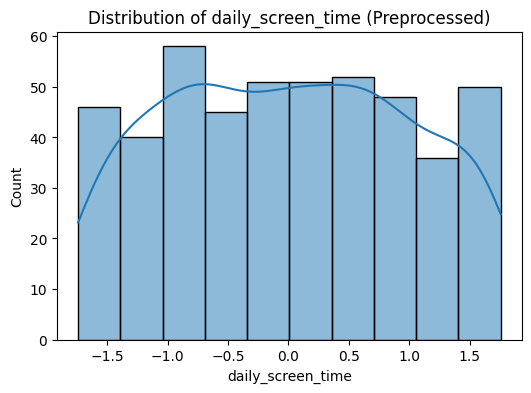

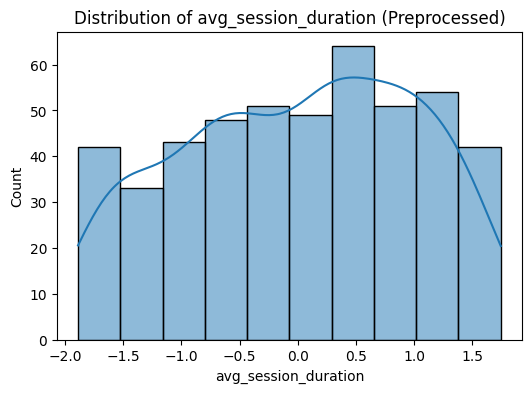

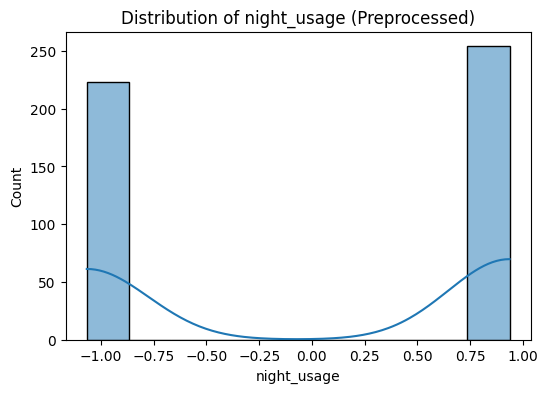

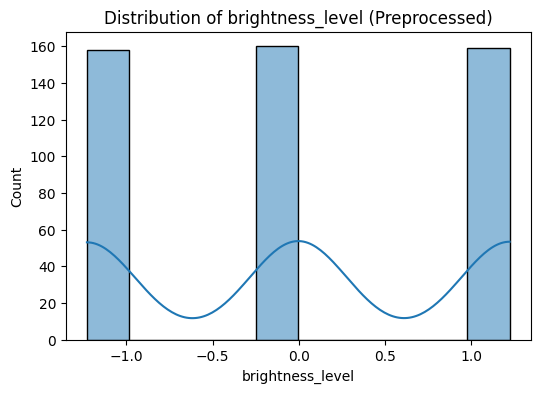

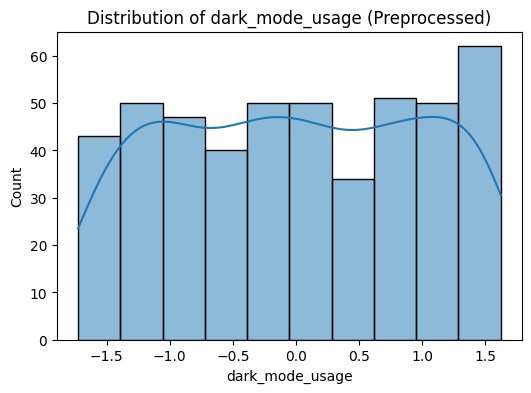

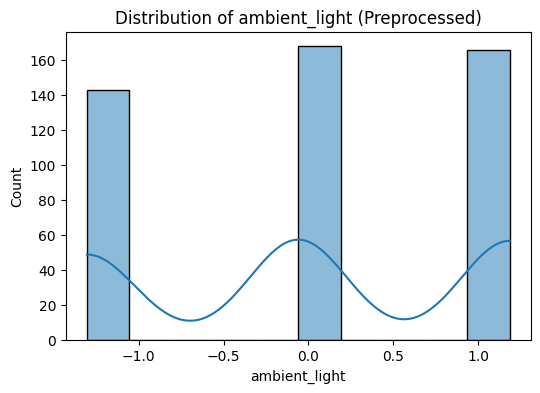

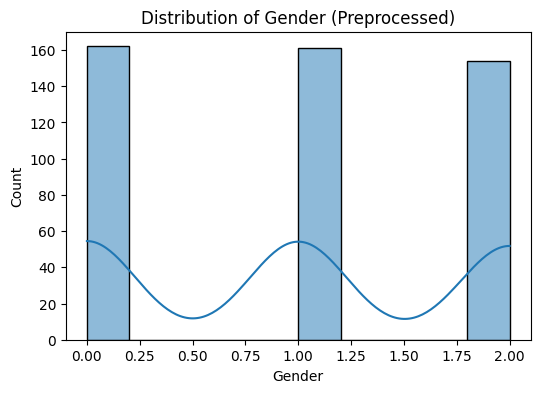

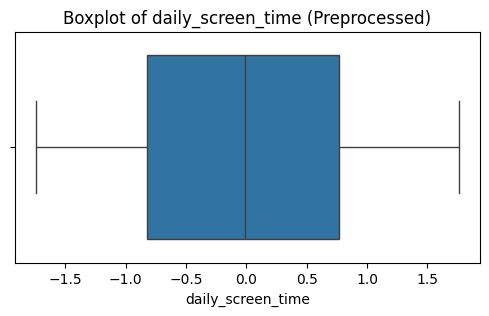

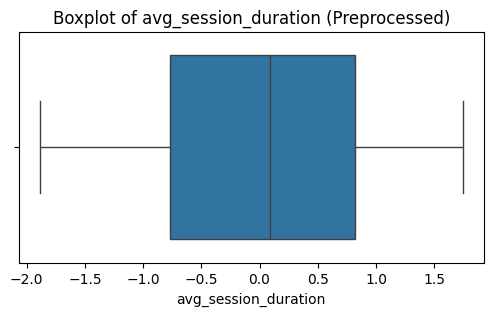

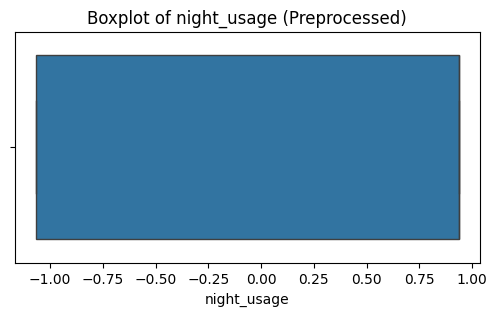

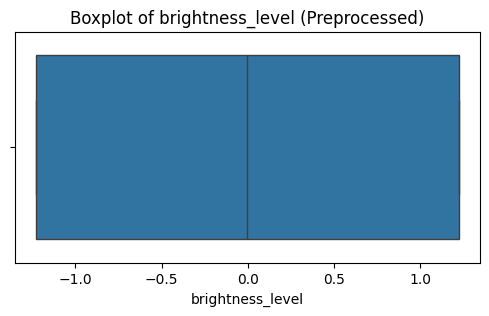

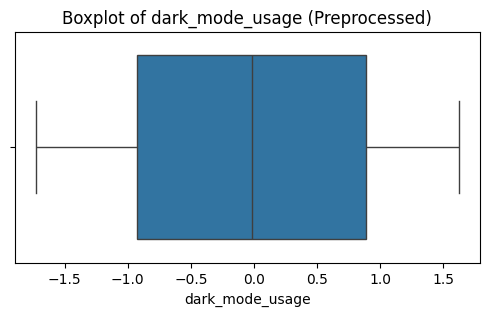

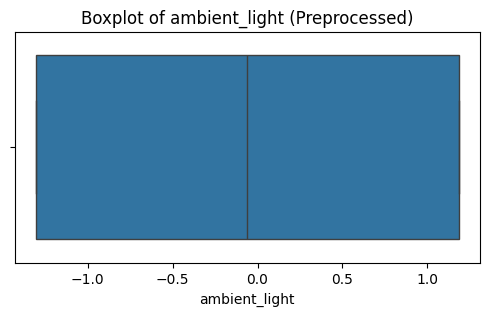

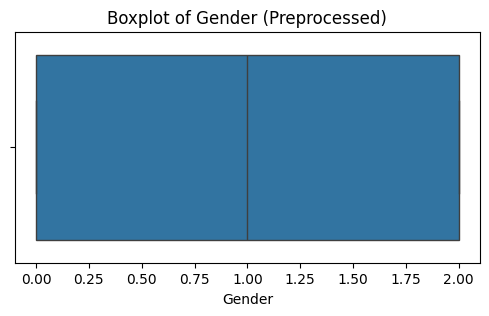

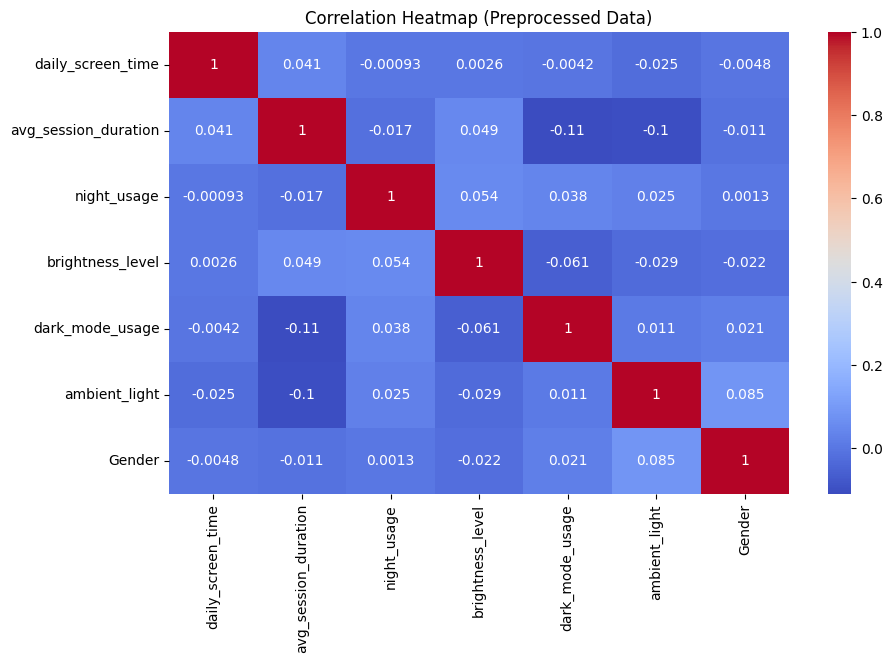


EDA on preprocessed data completed successfully ✅


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Eye_strain_dataset_preprocessed.csv")

print("Shape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)

print("\nDataset Info:\n")
df.info()

print("\nFirst 5 Rows:\n")
print(df.head())

print("\nStatistical Summary:\n")
print(df.describe())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col} (Preprocessed)")
    plt.show()

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col} (Preprocessed)")
    plt.show()

plt.figure(figsize=(10,6))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Preprocessed Data)")
plt.show()

print("\nEDA on preprocessed data completed successfully ✅")


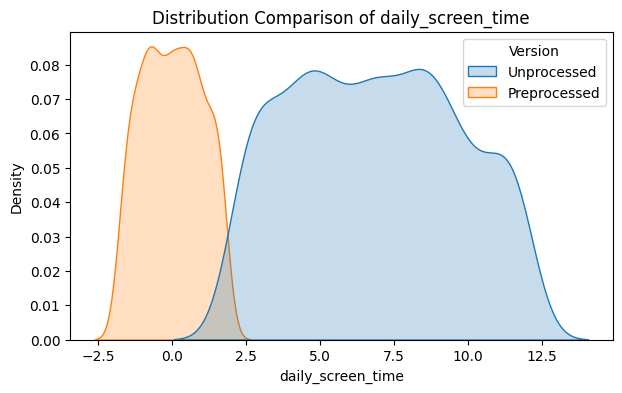

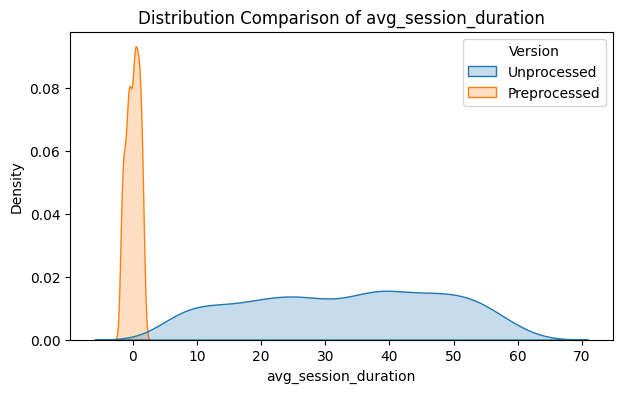

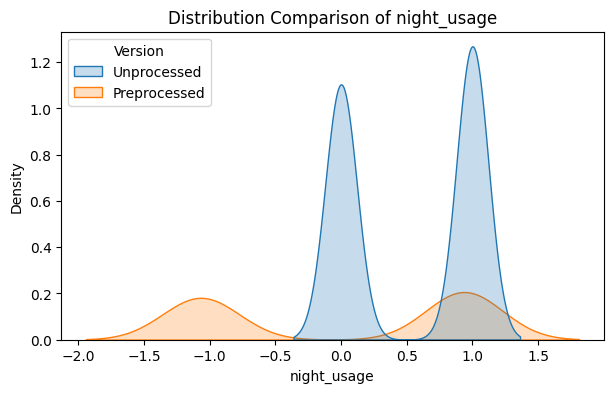

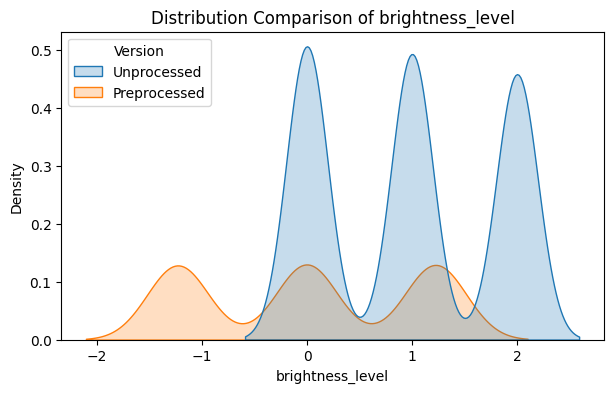

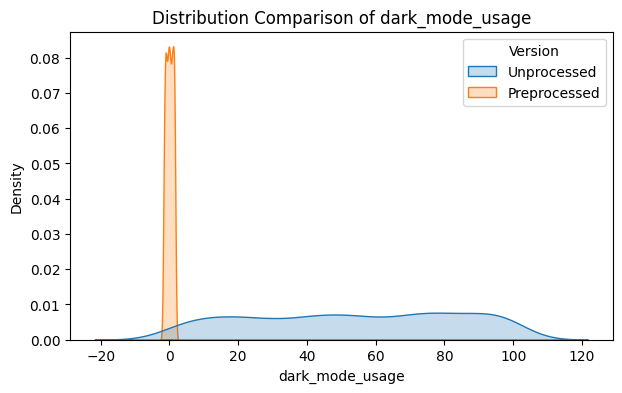

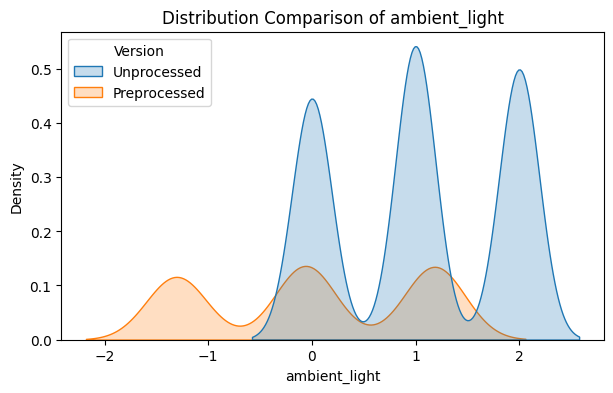

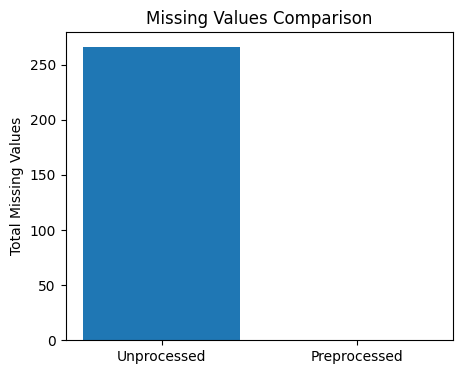

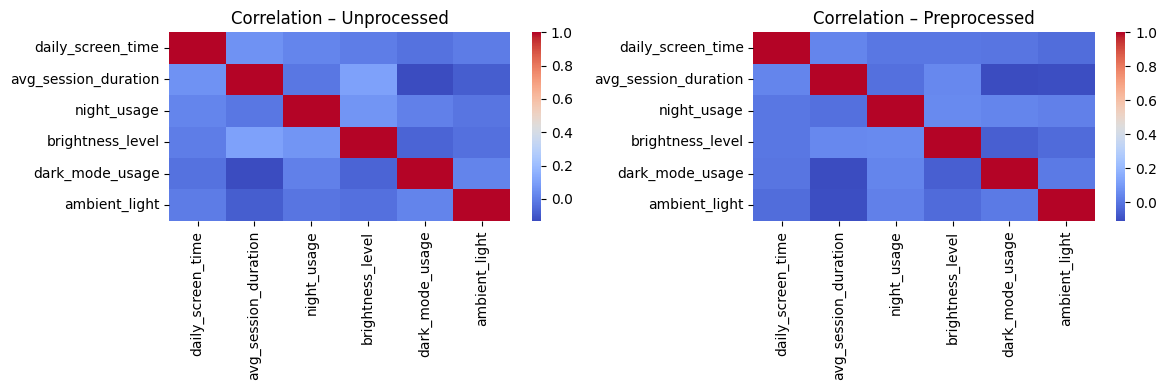

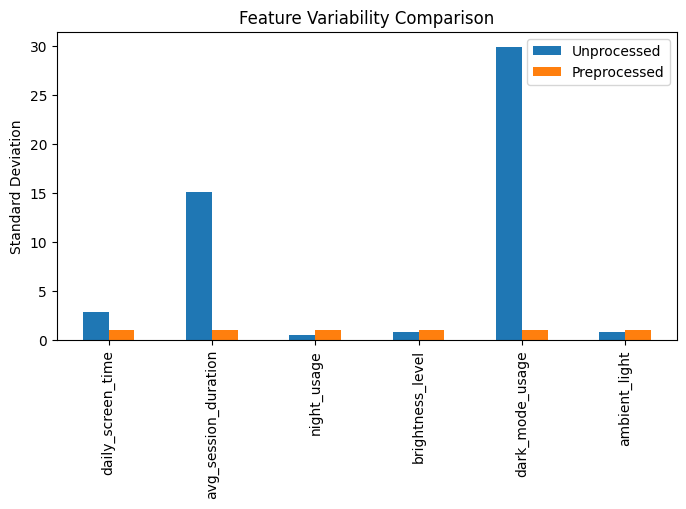

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

raw_df = pd.read_csv("Eye_strain_dataset.csv")
prep_df = pd.read_csv("Eye_strain_dataset_preprocessed.csv")

raw_df["Version"] = "Unprocessed"
prep_df["Version"] = "Preprocessed"

combined_df = pd.concat([raw_df, prep_df], ignore_index=True)

num_cols = raw_df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=combined_df, x=col, hue="Version", fill=True)
    plt.title(f"Distribution Comparison of {col}")
    plt.show()

raw_missing = raw_df.isnull().sum().sum()
prep_missing = prep_df.isnull().sum().sum()

plt.figure(figsize=(5,4))
plt.bar(["Unprocessed", "Preprocessed"], [raw_missing, prep_missing])
plt.title("Missing Values Comparison")
plt.ylabel("Total Missing Values")
plt.show()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.heatmap(raw_df[num_cols].corr(), cmap="coolwarm")
plt.title("Correlation – Unprocessed")

plt.subplot(1,2,2)
sns.heatmap(prep_df[num_cols].corr(), cmap="coolwarm")
plt.title("Correlation – Preprocessed")

plt.tight_layout()
plt.show()

raw_std = raw_df[num_cols].std()
prep_std = prep_df[num_cols].std()

std_df = pd.DataFrame({
    "Unprocessed": raw_std,
    "Preprocessed": prep_std
})

std_df.plot(kind="bar", figsize=(8,4))
plt.title("Feature Variability Comparison")
plt.ylabel("Standard Deviation")
plt.show()


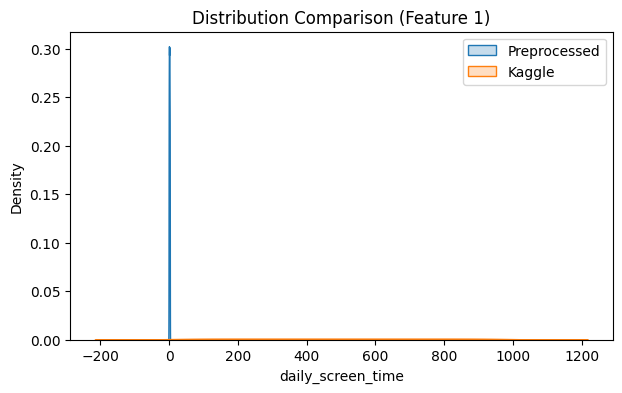

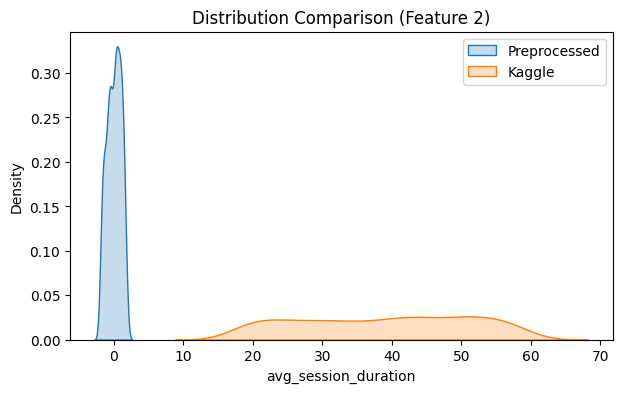

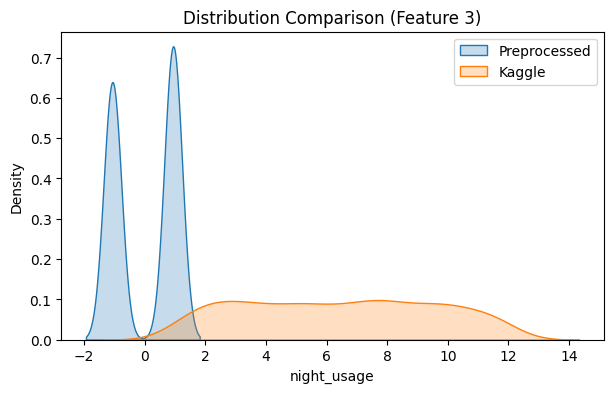

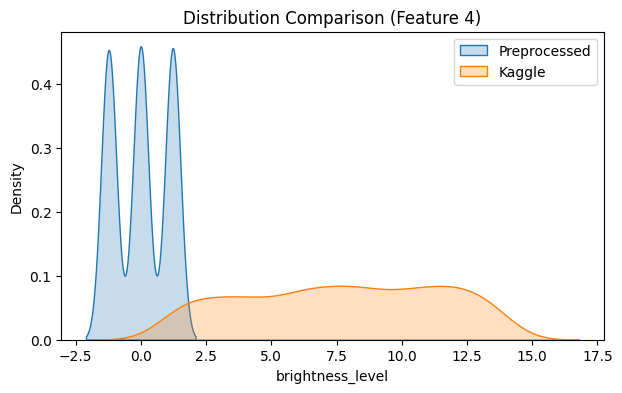

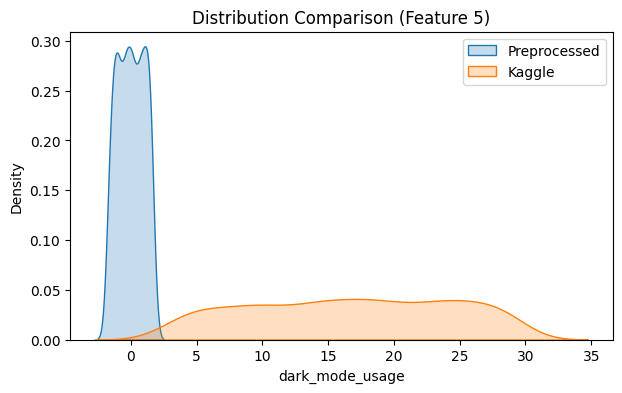

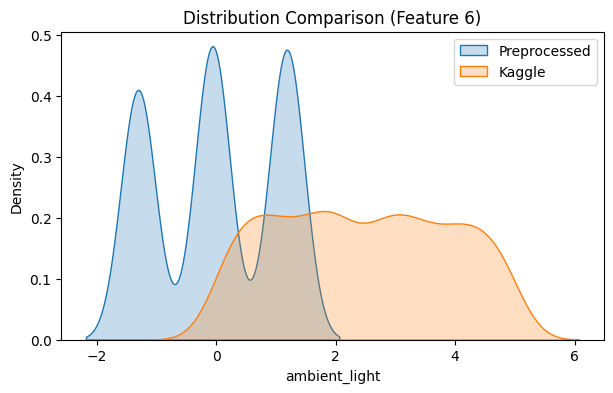

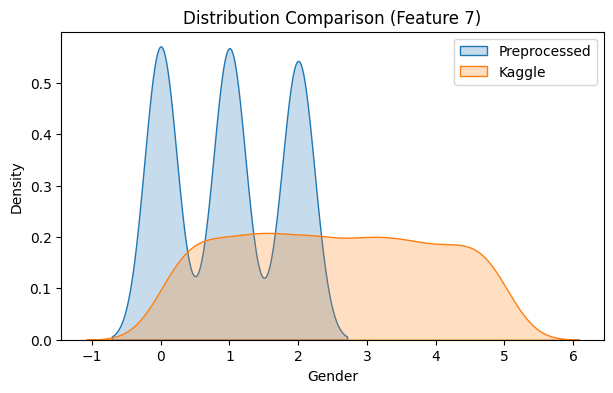

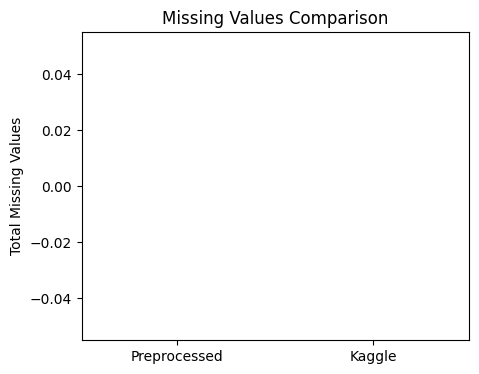

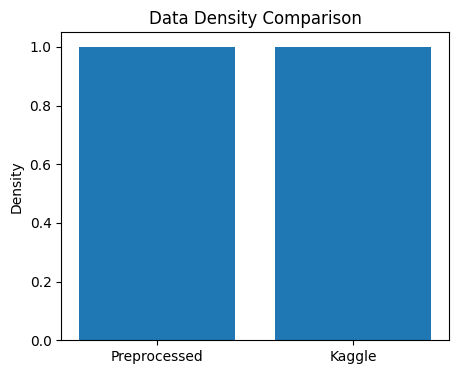

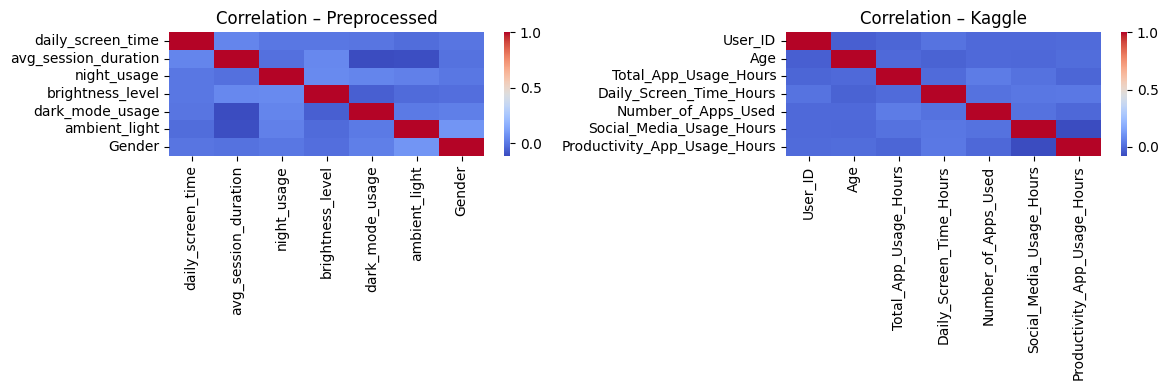

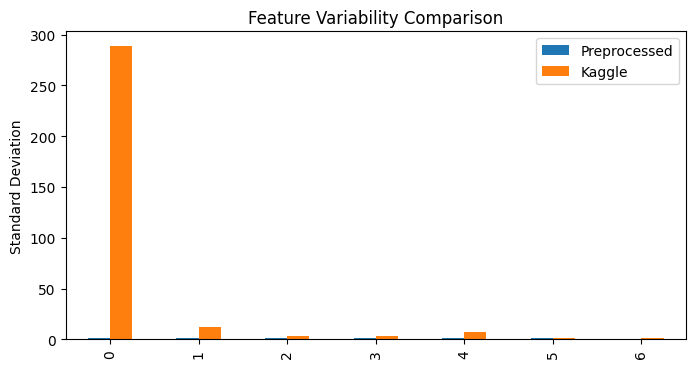

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

prep_df = pd.read_csv("Eye_strain_dataset_preprocessed.csv")
kaggle_df = pd.read_csv("Kaggle_dataset.csv")

prep_num = prep_df.select_dtypes(include=np.number)
kaggle_num = kaggle_df.select_dtypes(include=np.number)

min_features = min(prep_num.shape[1], kaggle_num.shape[1])

prep_num = prep_num.iloc[:, :min_features]
kaggle_num = kaggle_num.iloc[:, :min_features]

for i in range(min_features):
    plt.figure(figsize=(7,4))
    sns.kdeplot(prep_num.iloc[:, i], label="Preprocessed", fill=True)
    sns.kdeplot(kaggle_num.iloc[:, i], label="Kaggle", fill=True)
    plt.title(f"Distribution Comparison (Feature {i+1})")
    plt.legend()
    plt.show()

prep_missing = prep_df.isnull().sum().sum()
kaggle_missing = kaggle_df.isnull().sum().sum()

plt.figure(figsize=(5,4))
plt.bar(["Preprocessed", "Kaggle"], [prep_missing, kaggle_missing])
plt.title("Missing Values Comparison")
plt.ylabel("Total Missing Values")
plt.show()

prep_density = 1 - (prep_missing / prep_df.size)
kaggle_density = 1 - (kaggle_missing / kaggle_df.size)

plt.figure(figsize=(5,4))
plt.bar(["Preprocessed", "Kaggle"], [prep_density, kaggle_density])
plt.title("Data Density Comparison")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.heatmap(prep_num.corr(), cmap="coolwarm")
plt.title("Correlation – Preprocessed")

plt.subplot(1,2,2)
sns.heatmap(kaggle_num.corr(), cmap="coolwarm")
plt.title("Correlation – Kaggle")

plt.tight_layout()
plt.show()

std_df = pd.DataFrame({
    "Preprocessed": prep_num.std().values,
    "Kaggle": kaggle_num.std().values
})

std_df.plot(kind="bar", figsize=(8,4))
plt.title("Feature Variability Comparison")
plt.ylabel("Standard Deviation")
plt.show()


In [2]:
df = pd.read_csv("Eye_strain_dataset.csv")

print("Columns in dataset:")
print(df.columns)


Columns in dataset:
Index(['daily_screen_time', 'avg_session_duration', 'night_usage',
       'brightness_level', 'dark_mode_usage', 'ambient_light', 'Gender'],
      dtype='object')
